# Book Seller to Star Schema
## First POC on Data Warehousing

```
This notebook demonstrates a simple 
end-to-end data warehousing proof of 
concept using a fictional "book seller".
```

### Goals

1. Load two operational tables: `sales` and `books`

2. Understand the transactional design

3. Design and build a star schema (a fact table and dimension tables)

4. Perform ETL from operational tables into dimensional tables and a fact table

5. Run business intelligence queries on the star schema

### Tools
- Python
- Pandas
- DuckDB

### Input files

The following files are generated from a transactional databases:

- `sales.csv` with 10,000 rows
- `books.csv` with 100 rows

---
#  What is a Star Schema?
# ⭐ Star Schema (Core Concept in Data Warehousing)


A **Star Schema** is a data model designed for **analytical queries (OLAP)**.

It consists of:

- **1 central FACT table** (measurable events)
- **Multiple DIMENSION tables** (descriptive context)

```
                    dim_location
                          |
                          |
    dim_book   ------ fact_sales  ------- dim_date
                          |
                          |
                    dim_book_format
```

---

## Key Characteristics of a Star Schema

- Simple and intuitive structure
- Optimized for **fast queries**
- Uses **joins between fact and dimensions**
- Supports **aggregation and reporting**

---

## Why use Star Schema?

- Faster analytics
- Cleaner queries
- Better organization of data
- Scales for large datasets

---

## Example in this project

- **fact_sales** → transactions
- **dim_book** → book details
- **dim_location** → geography
- **dim_date** → time
- **dim_book_format** → format of book

---
# 📄 Slide 2 — Fact Table vs Dimension Tables

## 🟡 Fact Table (fact_sales)

### What is it?

Stores **business events** (transactions)

### Contains:

- **Foreign Keys**
  - book_id
  - date_id
  - location_id

- **Measures (numeric values)**
  - sale_price
  - discount
  - final_price

---

### Example:

| transaction_id | book_id | date_id | revenue |
|----------------|--------|--------|---------|
| 1001           | 10     | 25     | 20.00   |

---

## 🟢 Dimension Tables

### What are they?

Store **descriptive attributes**

---

### Examples:

#### dim_book
- book_title
- genre
- publisher

#### dim_location
- country
- city

#### dim_date
- year
- month
- day

---

## 🔥 Key Differences

| Feature | Fact Table | Dimension Table |
|--------|-----------|----------------|
| Purpose | Store events | Describe data |
| Size | Large | Small |
| Data | Numeric | Text / attributes |
| Updates | Frequent | Rare |

---

## 🧠 Key Insight

* Fact table = “What happened?”

* Dimension tables = “Context of what happened”


---
### Data Quality

#### NOTE-1: For this notebook, all of data is clean
#### NOTE-2: In the next iterations, we will deal with "messy" data

---
# Cell Description
### 1. Import required libraries
### 2. Define Data location

In [1]:
import pandas as pd
from pathlib import Path

# define the folder where data files are
DATA_DIR = Path("./data")

sales_file = DATA_DIR / "sales.csv"
# sales_file = "./data/sales.csv"

books_file = DATA_DIR / "books.csv"
# books_file = "./data/books.csv"

print("sales.csv file exists:", sales_file.exists())
print("books.csv file exists:", books_file.exists())

sales.csv file exists: True
books.csv file exists: True


---
# Create a DuckDB Connection object as con

In [2]:
import duckdb

# create a DuckDB Connection Object as con:
con = duckdb.connect()

# print for debugging purposes
print("DuckDB version: ", duckdb.__version__)
print("DuckDB conection object:", con)

DuckDB version:  1.4.4
DuckDB conection object: <_duckdb.DuckDBPyConnection object at 0x1112ecdb0>


## 1. Load the operational tables

These are the original transactional tables. In a real system, they might come from an OLTP database, application exports, or APIs.

For this first POC, the data is clean on purpose so we can focus on dimensional modeling and ETL.


In [3]:
sales_df = pd.read_csv(sales_file, parse_dates=["date_sold"])
books_df = pd.read_csv(books_file, parse_dates=["published_date"])

print("sales_df shape:", sales_df.shape)
print("books_df shape:", books_df.shape)


sales_df shape: (10000, 15)
books_df shape: (100, 7)


In [4]:
sales_df.head()

,transaction_id,book_id,sale_type,date_sold,year_sold,month_sold,day_sold,sale_price,discount,final_price,country_sold,city_sold,hard_copy,paperback,soft_copy
0,1,81,ONLINE,2024-03-04,2024,3,4,21.09,1.05,20.04,Germany,Munich,False,True,False
1,2,28,INSTORE,2025-01-24,2025,1,24,53.20,0.00,53.20,USA,Chicago,True,False,False
2,3,77,ONLINE,2025-07-05,2025,7,5,29.42,0.00,29.42,Germany,Munich,False,True,False
3,4,15,INSTORE,2024-01-30,2024,1,30,20.85,3.13,17.72,Germany,Munich,False,True,False
4,5,80,ONLINE,2024-05-10,2024,5,10,20.48,2.05,18.43,Canada,Vancouver,False,True,False


In [5]:
books_df.head()

,book_id,book_title,book_genre,author_id,author_name,author_web_site,published_date
0,1,Advanced Analytics 1,History,36,Morgan Johnson,https://authors.example.com/morgan-johnson-36,2020-07-27
1,2,Guide to Retail 2,Business,3,Taylor Lee,https://authors.example.com/taylor-lee-3,2018-09-29
2,3,Advanced SQL 3,Mystery,14,Morgan Smith,https://authors.example.com/morgan-smith-14,2023-08-07
3,4,Learning Retail 4,Data Science,26,Morgan Clark,https://authors.example.com/morgan-clark-26,2019-07-26
4,5,Inside Retail 5,Children,16,Jamie Garcia,https://authors.example.com/jamie-garcia-16,2024-07-22


## 2. Create DuckDB tables for the operational model

We now load the CSV files into DuckDB so we can use SQL for transformation and analytics.


In [6]:
con.execute("DROP TABLE IF EXISTS sales")
con.execute("DROP TABLE IF EXISTS books")

con.from_df(sales_df).create("sales")
con.from_df(books_df).create("books")

con.execute("SHOW TABLES").df()

,name
0,books
1,sales


## 3. Understand the transactional schema

The `sales` table mixes several concerns:
- transaction information
- date information
- location information
- book format information

The `books` table contains book and author attributes.

This is acceptable for transactions, but it is not ideal for analytics at scale. A star schema makes reporting easier and faster.


In [7]:
print("Sales schema:")
print(con.execute("DESCRIBE sales").df().to_string(index=False))

Sales schema:
   column_name  column_type null  key default extra
transaction_id       BIGINT  YES None    None  None
       book_id       BIGINT  YES None    None  None
     sale_type      VARCHAR  YES None    None  None
     date_sold TIMESTAMP_NS  YES None    None  None
     year_sold       BIGINT  YES None    None  None
    month_sold       BIGINT  YES None    None  None
      day_sold       BIGINT  YES None    None  None
    sale_price       DOUBLE  YES None    None  None
      discount       DOUBLE  YES None    None  None
   final_price       DOUBLE  YES None    None  None
  country_sold      VARCHAR  YES None    None  None
     city_sold      VARCHAR  YES None    None  None
     hard_copy      BOOLEAN  YES None    None  None
     paperback      BOOLEAN  YES None    None  None
     soft_copy      BOOLEAN  YES None    None  None


In [8]:
print("\nBooks schema:")
print(con.execute("DESCRIBE books").df().to_string(index=False))


Books schema:
    column_name  column_type null  key default extra
        book_id       BIGINT  YES None    None  None
     book_title      VARCHAR  YES None    None  None
     book_genre      VARCHAR  YES None    None  None
      author_id       BIGINT  YES None    None  None
    author_name      VARCHAR  YES None    None  None
author_web_site      VARCHAR  YES None    None  None
 published_date TIMESTAMP_NS  YES None    None  None


## 4. Proposed star schema

We will create the following dimensional model:

### Dimension tables
1. `dim_book`
   - book information and author attributes
2. `dim_location`
   - country and city where the book was sold
3. `dim_date`
   - one row per sold date
4. `dim_book_format`
   - hard copy / paperback / soft copy

### Fact table
5. `fact_sales`
   - one row per transaction
   - foreign keys to dimensions
   - measures such as `sale_price`, `discount`, and `final_price`

This is a simple, practical star schema for teaching and BI work.


## 5. ETL Step A: Create dimension tables

We start by extracting unique descriptive entities from the operational tables.


In [9]:
con.execute("DROP TABLE IF EXISTS dim_book")
con.execute("""
CREATE TABLE dim_book AS
SELECT
    book_id,
    book_title,
    book_genre,
    author_id,
    author_name,
    author_web_site,
    published_date
FROM books
ORDER BY book_id
""")

con.execute("SELECT COUNT(*) AS dim_book_rows FROM dim_book").df()

,dim_book_rows
0,100


In [10]:
five_rows = con.execute("SELECT * FROM dim_book LIMIT 5").df()
five_rows

,book_id,book_title,book_genre,author_id,author_name,author_web_site,published_date
0,1,Advanced Analytics 1,History,36,Morgan Johnson,https://authors.example.com/morgan-johnson-36,2020-07-27
1,2,Guide to Retail 2,Business,3,Taylor Lee,https://authors.example.com/taylor-lee-3,2018-09-29
2,3,Advanced SQL 3,Mystery,14,Morgan Smith,https://authors.example.com/morgan-smith-14,2023-08-07
3,4,Learning Retail 4,Data Science,26,Morgan Clark,https://authors.example.com/morgan-clark-26,2019-07-26
4,5,Inside Retail 5,Children,16,Jamie Garcia,https://authors.example.com/jamie-garcia-16,2024-07-22


---
# Create Location Dimension Table as `dim_location` table.

### Note that `location_id` is a "surrogate key"

### What is a surrogate key?
    
```
    A surrogate key is a unique, system-generated, 
    and business-meaningless value (often an integer 
    or UUID) used as a database table's primary key. 
    Unlike natural keys, they have no intrinsic meaning, 
    ensuring consistent identification regardless of data 
    changes. Common examples include AUTO_INCREMENT, 
    IDENTITY columns, or sequences. 
```

#### Here, a pair of `(country, city)` is represented by a `location_id`.

In [11]:
con.execute("DROP TABLE IF EXISTS dim_location")
con.execute("""
CREATE TABLE dim_location AS
SELECT
    ROW_NUMBER() OVER (ORDER BY country_sold, city_sold) AS location_id,
    country_sold AS country,
    city_sold AS city
FROM (
    SELECT DISTINCT country_sold, city_sold
    FROM sales
)
ORDER BY country, city
""")

con.execute("SELECT * FROM dim_location ORDER BY location_id").df()

,location_id,country,city
0,1,Australia,Brisbane
1,2,Australia,Melbourne
2,3,Australia,Sydney
3,4,Canada,Montreal
4,5,Canada,Toronto
5,6,Canada,Vancouver
6,7,Germany,Berlin
7,8,Germany,Hamburg
8,9,Germany,Munich
9,10,UK,Bristol


---
# Create Date Dimension table as `dim_date`

```
   date_id is a "surrogate key" and acts 
   as a PK for the `dim_date` table
```

In [12]:
con.execute("DROP TABLE IF EXISTS dim_date")
con.execute("""
CREATE TABLE dim_date AS
SELECT
    ROW_NUMBER() OVER (ORDER BY date_sold) AS date_id,
    date_sold,
    year(date_sold) AS year_sold,
    month(date_sold) AS month_sold,
    day(date_sold) AS day_sold,
    dayname(date_sold) AS day_name,
    quarter(date_sold) AS quarter_num
FROM (
    SELECT DISTINCT date_sold
    FROM sales
)
ORDER BY date_sold
""")

con.execute("SELECT * FROM dim_date ORDER BY date_id LIMIT 10").df()

,date_id,date_sold,year_sold,month_sold,day_sold,day_name,quarter_num
0,1,2024-01-01,2024,1,1,Monday,1
1,2,2024-01-02,2024,1,2,Tuesday,1
2,3,2024-01-03,2024,1,3,Wednesday,1
3,4,2024-01-04,2024,1,4,Thursday,1
4,5,2024-01-05,2024,1,5,Friday,1
5,6,2024-01-06,2024,1,6,Saturday,1
6,7,2024-01-07,2024,1,7,Sunday,1
7,8,2024-01-08,2024,1,8,Monday,1
8,9,2024-01-09,2024,1,9,Tuesday,1
9,10,2024-01-10,2024,1,10,Wednesday,1


---
# Create Book Format Dimension table as `dim_book_format`

```
   format_id is a "surrogate key" and acts 
   as a PK for the `dim_book_format` table
```

In [13]:
con.execute("DROP TABLE IF EXISTS dim_book_format")
con.execute("""
CREATE TABLE dim_book_format AS
SELECT 1 AS format_id, 'HARDCOPY' AS format_name
UNION ALL
SELECT 2 AS format_id, 'PAPERBACK' AS format_name
UNION ALL
SELECT 3 AS format_id, 'SOFTCOPY' AS format_name
ORDER BY format_id
""")

con.execute("SELECT * FROM dim_book_format").df()

,format_id,format_name
0,1,HARDCOPY
1,2,PAPERBACK
2,3,SOFTCOPY


---

## 6. ETL Step B: Create the fact table as `fact_sales`

```
Now we map each transaction to its dimension keys 
and keep the measurable attributes (sale_price,
discount, final_price, ...) in the fact table.
```

#### What is a Fact Table in Star Schema?
```
A fact table is the central hub of a star schema in a 
data warehouse, storing quantitative metrics (measures) 
such as sales amounts, quantities, or prices. It connects 
to surrounding dimension tables via foreign keys to enable 
analysis of business events. Fact tables are typically very 
large, containing millions of rows, and are optimized for 
fast aggregation. 
```

In [14]:
con.execute("DROP TABLE IF EXISTS fact_sales")
con.execute("""
CREATE TABLE fact_sales AS
WITH sales_enriched AS (
    SELECT
        s.transaction_id,
        s.book_id,
        s.sale_type,
        s.date_sold,
        s.sale_price,
        s.discount,
        s.final_price,
        s.country_sold,
        s.city_sold,
        CASE
            WHEN s.hard_copy THEN 'HARDCOPY'
            WHEN s.paperback THEN 'PAPERBACK'
            WHEN s.soft_copy THEN 'SOFTCOPY'
        END AS format_name
    FROM sales s
)
SELECT
    se.transaction_id,
    d.date_id,
    b.book_id,
    l.location_id,
    f.format_id,
    se.sale_type,
    1 AS quantity_sold,
    se.sale_price,
    se.discount,
    se.final_price
FROM sales_enriched se
JOIN dim_book b
    ON se.book_id = b.book_id
JOIN dim_location l
    ON se.country_sold = l.country
   AND se.city_sold = l.city
JOIN dim_date d
    ON se.date_sold = d.date_sold
JOIN dim_book_format f
    ON se.format_name = f.format_name
ORDER BY se.transaction_id
""")

con.execute("SELECT COUNT(*) AS fact_rows FROM fact_sales").df()

,fact_rows
0,10000


In [15]:
con.execute("SELECT * FROM fact_sales LIMIT 10").df()

,transaction_id,date_id,book_id,location_id,format_id,sale_type,quantity_sold,sale_price,discount,final_price
0,1,64,81,9,2,ONLINE,1,21.09,1.05,20.04
1,2,390,28,13,1,INSTORE,1,53.20,0.00,53.20
2,3,552,77,9,2,ONLINE,1,29.42,0.00,29.42
3,4,30,15,9,2,INSTORE,1,20.85,3.13,17.72
4,5,131,80,6,2,ONLINE,1,20.48,2.05,18.43
5,6,659,61,14,1,INSTORE,1,28.98,5.80,23.18
6,7,267,18,5,2,INSTORE,1,26.97,0.00,26.97
7,8,389,52,12,2,INSTORE,1,24.19,0.00,24.19
8,9,553,83,7,2,ONLINE,1,18.97,0.00,18.97
9,10,254,66,14,1,ONLINE,1,32.19,3.22,28.97


---

## 7. Validate the star schema

A quick sanity check:
- `fact_sales` should have the same number of rows as the transactional `sales` table
- location dimension should contain 15 rows
- book dimension should contain 100 rows


In [16]:
validation_sql = '''
SELECT 'sales' AS table_name, COUNT(*) AS row_count FROM sales
UNION ALL
SELECT 'fact_sales' AS table_name, COUNT(*) AS row_count FROM fact_sales
UNION ALL
SELECT 'dim_book' AS table_name, COUNT(*) AS row_count FROM dim_book
UNION ALL
SELECT 'dim_location' AS table_name, COUNT(*) AS row_count FROM dim_location
UNION ALL
SELECT 'dim_date' AS table_name, COUNT(*) AS row_count FROM dim_date
UNION ALL
SELECT 'dim_book_format' AS table_name, COUNT(*) AS row_count FROM dim_book_format
'''
con.execute(validation_sql).df()

,table_name,row_count
0,sales,10000
1,fact_sales,10000
2,dim_book,100
3,dim_location,15
4,dim_date,731
5,dim_book_format,3


---

## 8. Star schema diagram

Conceptually:

- `fact_sales` links to:
  - `dim_book`
  - `dim_location`
  - `dim_date`
  - `dim_book_format`

This is the central idea of the star schema:
a **fact table** in the middle, and **dimension tables** around it.

```
                    dim_location
                          |
                          |
    dim_book   ------ fact_sales  ------- dim_date
                          |
                          |
                    dim_book_format
```


---

## 9. Business Intelligence questions

Here are three example BI questions:

1. Which book genres generate the highest revenue?
2. Which countries and cities generate the most sales?
3. How do sales vary by month and sale type?

We now answer them in SQL using the star schema



---
# ✅ Cell 1 — Revenue by Book Genre

## Objective

Understand which genres generate the most revenue.

Business Analysis

```
	•	Identifies top-performing genres
	•	Helps optimize inventory and marketing focus
	•	Likely insight: Data Science / Technology genres dominate
```

In [17]:
# ----------------------------------------
# Objective: Revenue by Book Genre
# ----------------------------------------

query = """
SELECT
    b.book_genre,
    SUM(f.final_price) AS total_revenue
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.book_genre
ORDER BY total_revenue DESC
"""

df = con.execute(query).df()
df


,book_genre,total_revenue
0,Fantasy,46453.73
1,Data Science,39129.46
2,History,29228.22
3,Business,28546.87
4,Technology,25220.41
5,Science Fiction,22376.34
6,Mystery,19160.38
7,Fiction,18449.47
8,Children,14324.65
9,Biography,12845.91


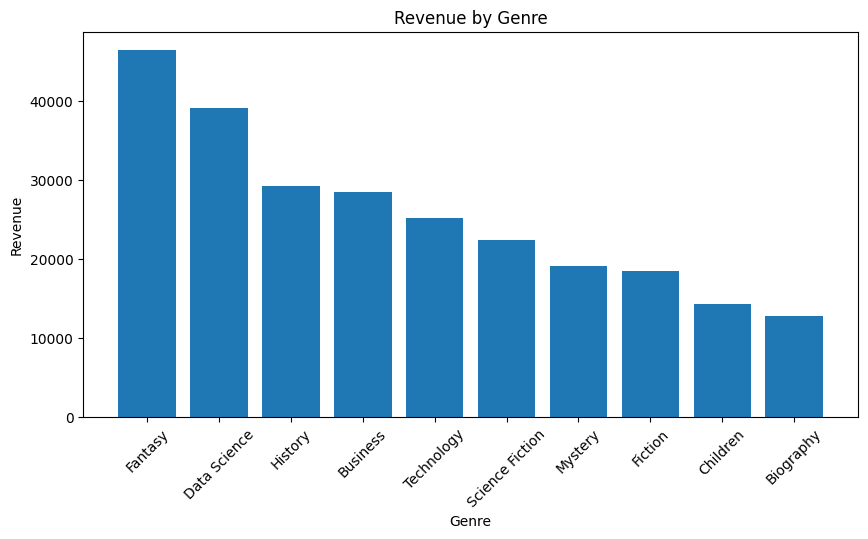

In [18]:
# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df["book_genre"], df["total_revenue"])
plt.title("Revenue by Genre")
plt.xlabel("Genre")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# ✅ Cell 2 — Top 10 Books by Revenue

## Objective

Find the most profitable books.

## Business Analysis

```
	•	Reveals best-selling products
	•	Useful for promotion & bundling strategies
	•	Can drive recommendation systems
```

In [19]:
query = """
SELECT
    b.book_title,
    SUM(f.final_price) AS revenue
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.book_title
ORDER BY revenue DESC
LIMIT 10
"""

df = con.execute(query).df()
df


,book_title,revenue
0,Practical Machine Learning 84,4807.66
1,Learning Retail 4,4713.65
2,Inside Data Warehousing 34,4641.28
3,Practical Bookselling 28,4409.01
4,Mastering Retail 97,4353.95
5,Learning Analytics 62,4149.61
6,Modern Cloud Systems 38,4135.63
7,The Data Warehousing 16,4104.43
8,Foundations of SQL 36,4044.59
9,Exploring Business Intelligence 49,3919.26


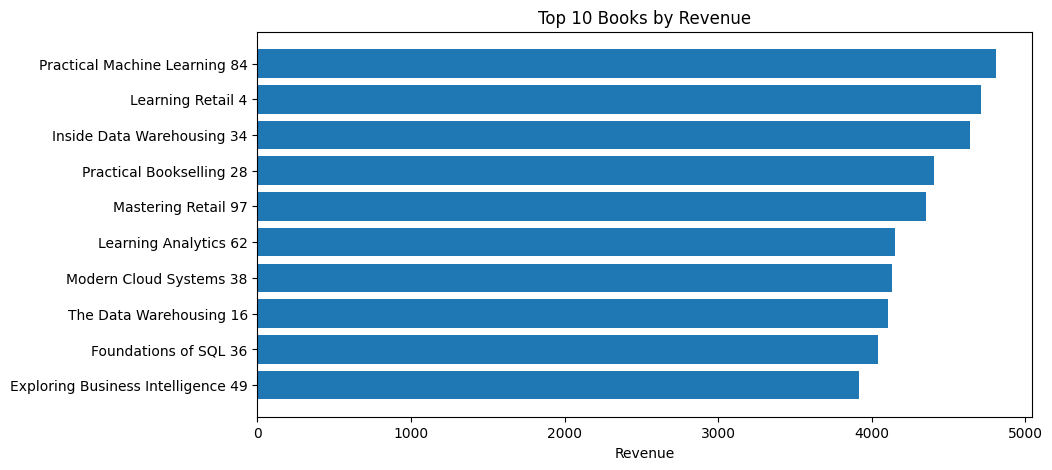

In [20]:
plt.figure(figsize=(10,5))
plt.barh(df["book_title"], df["revenue"])
plt.title("Top 10 Books by Revenue")
plt.xlabel("Revenue")
plt.gca().invert_yaxis()
plt.show()


---
# ✅ Cell 3 — Revenue by Country

## Objective

Identify strongest geographic markets.

## Business Analysis
```
	•	Shows top-performing countries
	•	Supports regional expansion decisions
	•	Helps optimize logistics and supply chains
```


In [21]:
query = """
SELECT
    l.country,
    SUM(f.final_price) AS revenue
FROM fact_sales f
JOIN dim_location l
  ON f.location_id = l.location_id
GROUP BY l.country
ORDER BY revenue DESC
"""

df = con.execute(query).df()
df


,country,revenue
0,Germany,52089.63
1,USA,51435.91
2,Canada,51287.17
3,UK,50989.63
4,Australia,49933.10


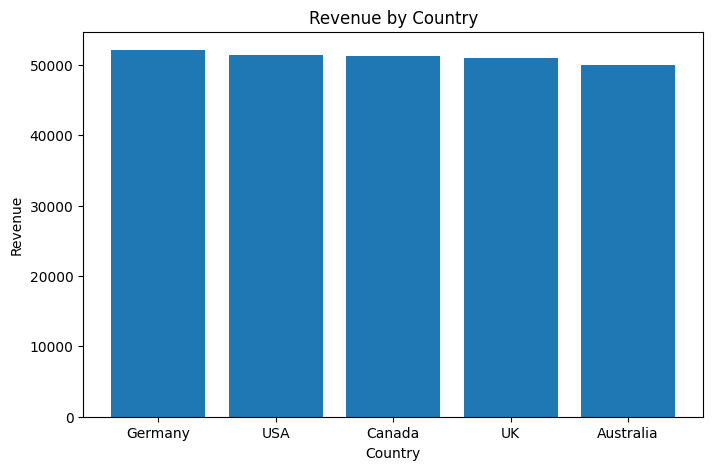

In [22]:
plt.figure(figsize=(8,5))
plt.bar(df["country"], df["revenue"])
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()


---
# ✅ Cell 4 — Top Cities by Sales Volume

## Objective

Find high-demand cities.

## Business Analysis
```
	•	Identifies urban demand centers
	•	Supports store placement decisions
	•	Useful for targeted advertising
```


In [23]:
query = """
SELECT
    l.city,
    COUNT(*) AS transactions
FROM fact_sales f
JOIN dim_location l
  ON f.location_id = l.location_id
GROUP BY l.city
ORDER BY transactions DESC
LIMIT 10
"""

df = con.execute(query).df()
df

,city,transactions
0,Munich,706
1,San Francisco,697
2,London,686
3,Vancouver,686
4,Berlin,684
5,Chicago,677
6,Melbourne,677
7,Montreal,663
8,Bristol,657
9,Manchester,656


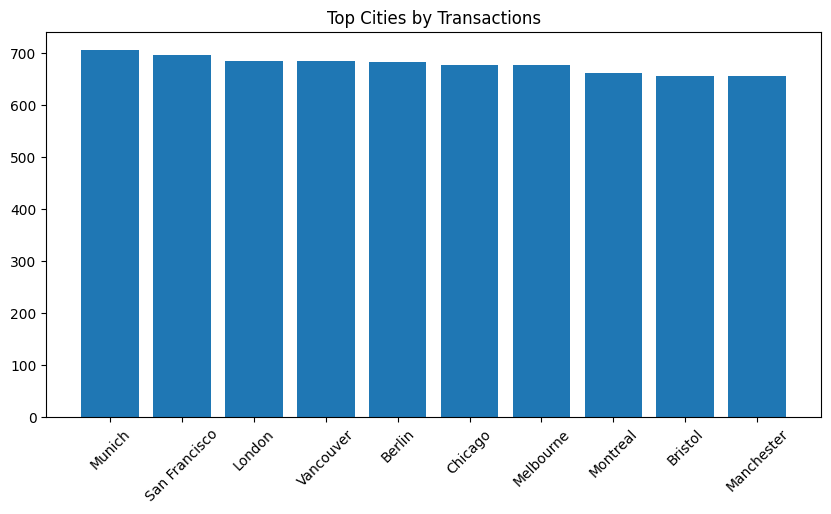

In [24]:
plt.figure(figsize=(10,5))
plt.bar(df["city"], df["transactions"])
plt.title("Top Cities by Transactions")
plt.xticks(rotation=45)
plt.show()


---
# ✅ Cell 5 — Monthly Revenue Trend

## Objective

Understand seasonality.

## Business Analysis
```
	•	Detects seasonal spikes
	•	Helps forecast future demand
	•	Important for inventory planning
```

In [25]:
query = """
SELECT
    d.year_sold,
    d.month_sold,
    SUM(f.final_price) AS revenue
FROM fact_sales f
JOIN dim_date d
  ON f.date_id = d.date_id
GROUP BY d.year_sold, d.month_sold
ORDER BY d.year_sold, d.month_sold
"""

df = con.execute(query).df()
df["year_month"] = df["year_sold"].astype(str) + "-" + df["month_sold"].astype(str)
df

,year_sold,month_sold,revenue,year_month
0,2024,1,10537.42,2024-1
1,2024,2,10352.68,2024-2
2,2024,3,11251.88,2024-3
3,2024,4,10977.56,2024-4
4,2024,5,10361.59,2024-5
5,2024,6,9169.49,2024-6
6,2024,7,10468.99,2024-7
7,2024,8,10899.11,2024-8
8,2024,9,10294.02,2024-9
9,2024,10,10839.13,2024-10


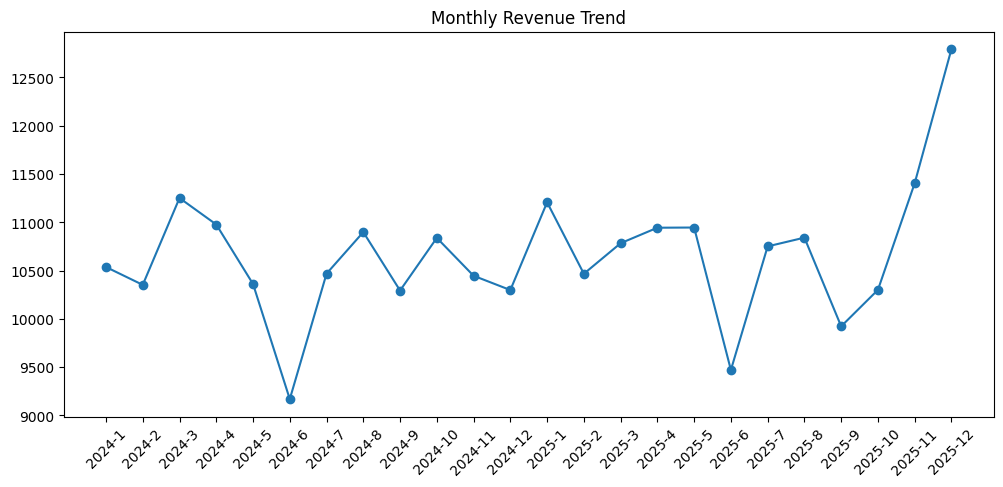

In [26]:
plt.figure(figsize=(12,5))
plt.plot(df["year_month"], df["revenue"], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

---
# ✅ Cell 6 — ONLINE vs INSTORE Revenue

## Objective

Compare sales channels.

## Business Analysis
```
	•	Measures digital vs physical performance
	•	Supports e-commerce strategy
	•	Helps resource allocation
```

In [27]:
query = """
SELECT
    sale_type,
    SUM(final_price) AS revenue
FROM fact_sales
GROUP BY sale_type
"""

df = con.execute(query).df()
df

,sale_type,revenue
0,INSTORE,131214.34
1,ONLINE,124521.10


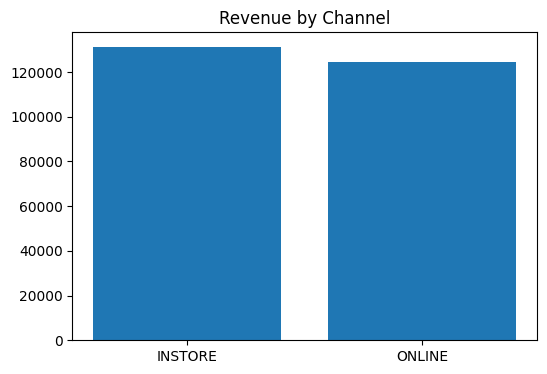

In [28]:
plt.figure(figsize=(6,4))
plt.bar(df["sale_type"], df["revenue"])
plt.title("Revenue by Channel")
plt.show()

---
# ✅ Cell 7 — Book Format Performance

## Objective

Compare format preferences.

## Business Analysis
```
	•	Reveals customer format preference
	•	Likely insight: soft copies growing
	•	Impacts publishing strategy
```

In [29]:
query = """
SELECT
    f2.format_name,
    SUM(f.final_price) AS revenue
FROM fact_sales f
JOIN dim_book_format f2
  ON f.format_id = f2.format_id
GROUP BY f2.format_name
ORDER BY revenue DESC
"""

df = con.execute(query).df()
df

,format_name,revenue
0,HARDCOPY,112397.00
1,PAPERBACK,78125.87
2,SOFTCOPY,65212.57


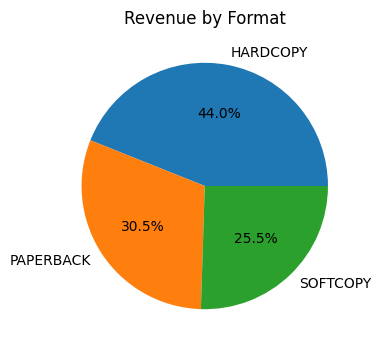

In [30]:
plt.figure(figsize=(6,4))
plt.pie(df["revenue"], labels=df["format_name"], autopct='%1.1f%%')
plt.title("Revenue by Format")
plt.show()

---
# ✅ Cell 8 — Discount Impact Analysis

## Objective

Measure how discounts affect revenue.

## Business Analysis
```
	•	Shows if discounts increase/decrease value
	•	Helps optimize pricing strategy
	•	Detects margin erosion risk
```

In [31]:
query = """
SELECT
    CASE 
        WHEN discount = 0 THEN 'No Discount'
        ELSE 'Discount Applied'
    END AS discount_flag,
    AVG(final_price) AS avg_revenue
FROM fact_sales
GROUP BY discount_flag
"""

df = con.execute(query).df()
df

,discount_flag,avg_revenue
0,No Discount,27.623397
1,Discount Applied,24.039738


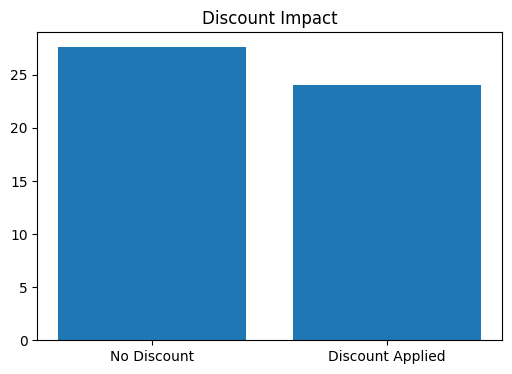

In [32]:
plt.figure(figsize=(6,4))
plt.bar(df["discount_flag"], df["avg_revenue"])
plt.title("Discount Impact")
plt.show()

---
# ✅ Cell 9 — Revenue by Day of Week

## Objective

Find behavioral patterns.

## Business Analysis
```
	•	Detects weekend vs weekday patterns
	•	Useful for campaign timing
	•	Supports staff scheduling
```


In [33]:
query = """
SELECT
    d.day_name,
    SUM(f.final_price) AS revenue
FROM fact_sales f
JOIN dim_date d
  ON f.date_id = d.date_id
GROUP BY d.day_name
"""

df = con.execute(query).df()
df

,day_name,revenue
0,Thursday,35934.14
1,Sunday,37610.93
2,Friday,35192.04
3,Saturday,37691.45
4,Tuesday,37114.57
5,Monday,34243.32
6,Wednesday,37948.99


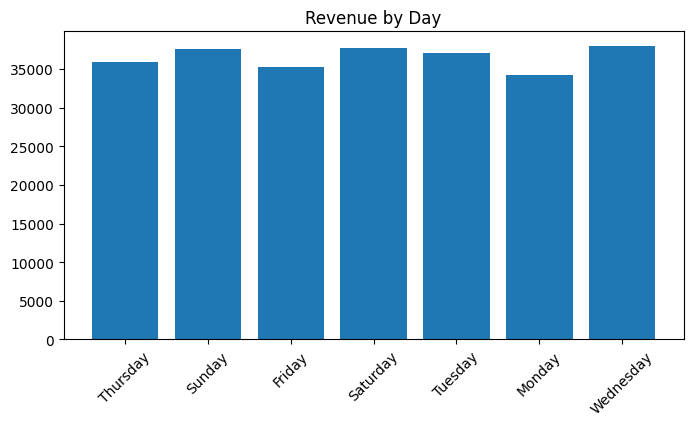

In [34]:
plt.figure(figsize=(8,4))
plt.bar(df["day_name"], df["revenue"])
plt.xticks(rotation=45)
plt.title("Revenue by Day")
plt.show()

---
# ✅ Cell 10 — Genre vs Channel Analysis (OLAP Cube Slice)

## Objective

Analyze interaction between dimensions.

## Business Analysis
```
	•	True OLAP-style multi-dimensional analysis Shows:
    	•	which genres perform better online
    	•	which require physical presence
    	•	Helps design channel-specific strategies
```


In [35]:
query = """
SELECT
    b.book_genre,
    f.sale_type,
    SUM(f.final_price) AS revenue
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.book_genre, f.sale_type
ORDER BY b.book_genre
"""

df = con.execute(query).df()
df

,book_genre,sale_type,revenue
0,Biography,INSTORE,6432.34
1,Biography,ONLINE,6413.57
2,Business,INSTORE,14466.61
3,Business,ONLINE,14080.26
4,Children,ONLINE,7039.95
5,Children,INSTORE,7284.70
6,Data Science,ONLINE,18986.47
7,Data Science,INSTORE,20142.99
8,Fantasy,ONLINE,22877.04
9,Fantasy,INSTORE,23576.69


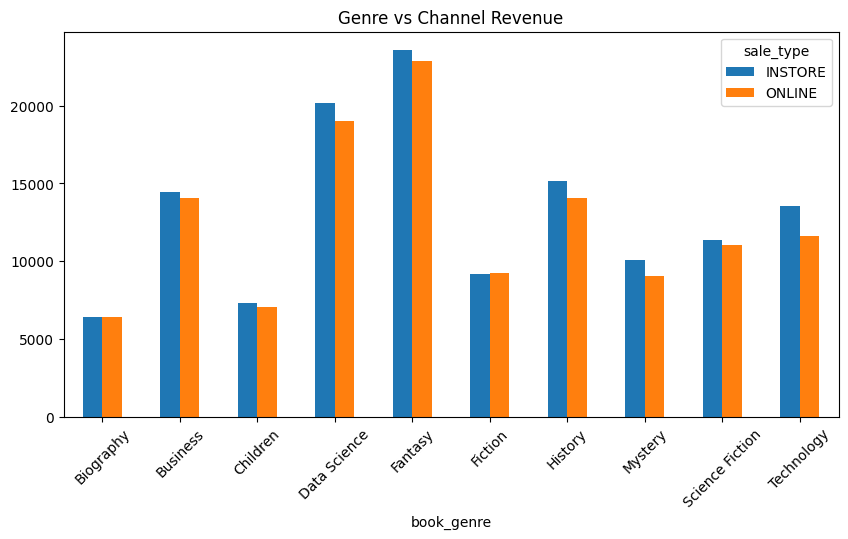

In [36]:
pivot_df = df.pivot(index="book_genre", columns="sale_type", values="revenue")

pivot_df.plot(kind="bar", figsize=(10,5))
plt.title("Genre vs Channel Revenue")
plt.xticks(rotation=45)
plt.show()

In [37]:
# Books Sales by Genre

q1 = '''
SELECT
    b.book_genre,
    COUNT(*) AS transactions,
    ROUND(SUM(f.final_price), 2) AS total_revenue
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.book_genre
ORDER BY total_revenue DESC
'''
genre_revenue = con.execute(q1).df()
genre_revenue

,book_genre,transactions,total_revenue
0,Fantasy,2080,46453.73
1,Data Science,938,39129.46
2,History,1093,29228.22
3,Business,998,28546.87
4,Technology,725,25220.41
5,Science Fiction,973,22376.34
6,Mystery,895,19160.38
7,Fiction,959,18449.47
8,Children,821,14324.65
9,Biography,518,12845.91


---
# Book Sales by Country and City

In [38]:
q2 = '''
SELECT
    l.country,
    l.city,
    COUNT(*) AS transactions,
    ROUND(SUM(f.final_price), 2) AS total_revenue
FROM fact_sales f
JOIN dim_location l
  ON f.location_id = l.location_id
GROUP BY l.country, l.city
ORDER BY total_revenue DESC
LIMIT 15
'''
location_revenue = con.execute(q2).df()
location_revenue

,country,city,transactions,total_revenue
0,Germany,Munich,706,18169.38
1,USA,San Francisco,697,18047.69
2,UK,London,686,17618.48
3,Canada,Vancouver,686,17608.66
4,Germany,Berlin,684,17482.53
5,USA,Chicago,677,17289.99
6,Australia,Melbourne,677,17262.78
7,Canada,Montreal,663,17071.69
8,UK,Manchester,656,16713.28
9,UK,Bristol,657,16657.87


In [39]:
# Book sales by Year, Month, and Sale_Type

q3 = '''
SELECT
    d.year_sold,
    d.month_sold,
    f.sale_type,
    COUNT(*) AS transactions,
    ROUND(SUM(f.final_price), 2) AS total_revenue
FROM fact_sales f
JOIN dim_date d
  ON f.date_id = d.date_id
GROUP BY d.year_sold, d.month_sold, f.sale_type
ORDER BY d.year_sold, d.month_sold, f.sale_type
'''
monthly_trend = con.execute(q3).df()
monthly_trend.head(20)

,year_sold,month_sold,sale_type,transactions,total_revenue
0,2024,1,INSTORE,211,5514.72
1,2024,1,ONLINE,211,5022.70
2,2024,2,INSTORE,211,5605.60
3,2024,2,ONLINE,191,4747.08
4,2024,3,INSTORE,222,5914.35
5,2024,3,ONLINE,223,5337.53
6,2024,4,INSTORE,231,6008.68
7,2024,4,ONLINE,198,4968.88
8,2024,5,INSTORE,205,5534.29
9,2024,5,ONLINE,195,4827.30


## 10. Optional visualization

For a first demo, a few simple plots help students see the value of the star schema quickly.


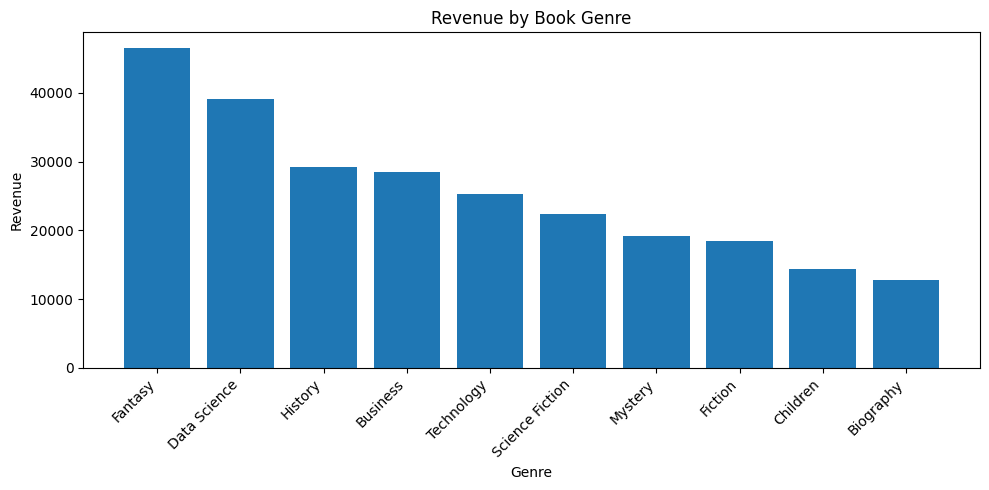

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(genre_revenue["book_genre"], genre_revenue["total_revenue"])
plt.title("Revenue by Book Genre")
plt.xlabel("Genre")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

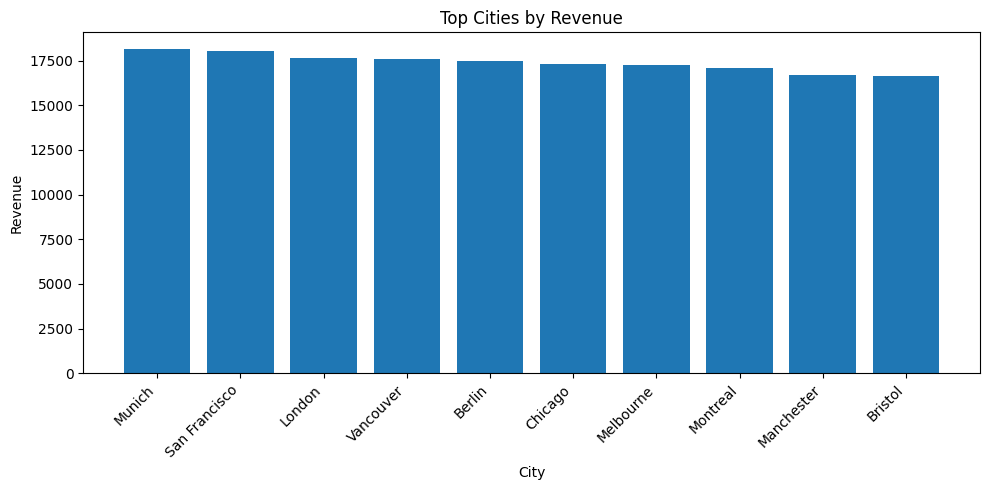

In [41]:
top_cities = location_revenue.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_cities["city"], top_cities["total_revenue"])
plt.title("Top Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

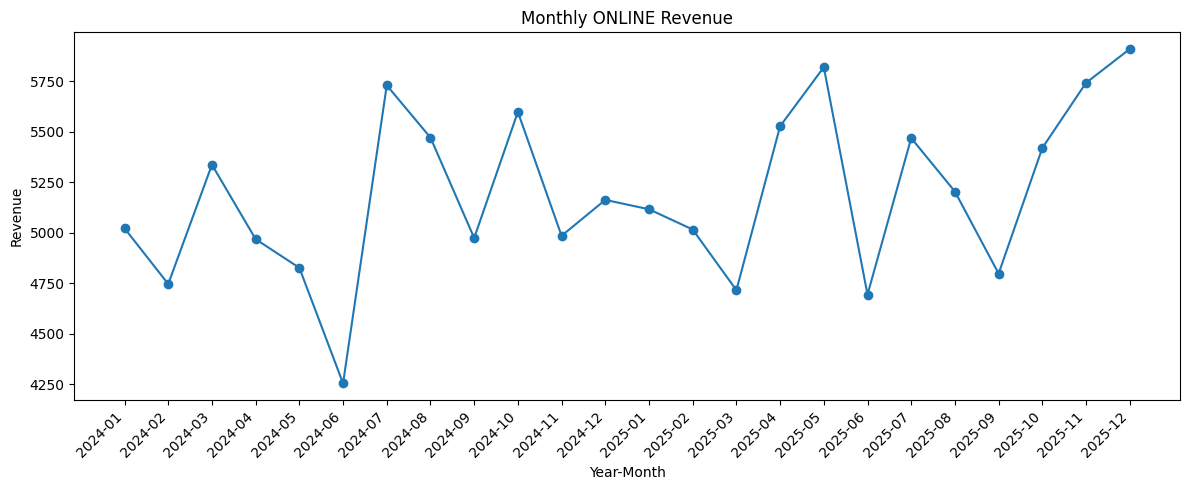

In [42]:
monthly_online = monthly_trend[monthly_trend["sale_type"] == "ONLINE"].copy()
monthly_online["year_month"] = (
    monthly_online["year_sold"].astype(str) + "-" +
    monthly_online["month_sold"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_online["year_month"], monthly_online["total_revenue"], marker="o")
plt.title("Monthly ONLINE Revenue")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. What we learned

This POC shows the core data warehousing flow:

1. Start with operational data
2. Identify descriptive entities for dimensions
3. Identify measurable events for the fact table
4. Build ETL to transform transactional data into a star schema
5. Use the star schema for reporting and BI SQL

This is a strong first demo for teaching dimensional modeling.


## 12. Suggested next steps

To extend this demo, you could add:

- `dim_sale_type` as a separate dimension
- `quantity_sold` values greater than 1
- inventory and publisher tables
- slowly changing dimensions
- a gold reporting layer with pre-aggregated marts
- dashboarding in Power BI, Tableau, or Streamlit
